In [43]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
features = pd.read_csv("Features data set.csv")
sales = pd.read_csv("sales data-set.csv")
stores = pd.read_csv("stores data-set.csv")

In [9]:
print(features.head(3))
print(sales.head(3))
print(stores.head(3))

   Store        Date  Temperature  Fuel_Price  MarkDown1  MarkDown2  \
0      1  05/02/2010        42.31       2.572        NaN        NaN   
1      1  12/02/2010        38.51       2.548        NaN        NaN   
2      1  19/02/2010        39.93       2.514        NaN        NaN   

   MarkDown3  MarkDown4  MarkDown5         CPI  Unemployment  IsHoliday  
0        NaN        NaN        NaN  211.096358         8.106      False  
1        NaN        NaN        NaN  211.242170         8.106       True  
2        NaN        NaN        NaN  211.289143         8.106      False  
   Store  Dept        Date  Weekly_Sales  IsHoliday
0      1     1  05/02/2010      24924.50      False
1      1     1  12/02/2010      46039.49       True
2      1     1  19/02/2010      41595.55      False
   Store Type    Size
0      1    A  151315
1      2    A  202307
2      3    B   37392


In [10]:
print(features.info())
print(sales.info())
print(stores.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         8190 non-null   int64  
 1   Date          8190 non-null   object 
 2   Temperature   8190 non-null   float64
 3   Fuel_Price    8190 non-null   float64
 4   MarkDown1     4032 non-null   float64
 5   MarkDown2     2921 non-null   float64
 6   MarkDown3     3613 non-null   float64
 7   MarkDown4     3464 non-null   float64
 8   MarkDown5     4050 non-null   float64
 9   CPI           7605 non-null   float64
 10  Unemployment  7605 non-null   float64
 11  IsHoliday     8190 non-null   bool   
dtypes: bool(1), float64(9), int64(1), object(1)
memory usage: 712.0+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store     

In [14]:
# Fixed the Fomrate of data 
sales['Date'] = pd.to_datetime(sales['Date'], dayfirst=True)
features['Date'] = pd.to_datetime(features['Date'], dayfirst=True)

In [25]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
dtypes: bool(1), datetime64[ns](1), float64(1), int64(2)
memory usage: 13.3 MB


In [26]:
# merge Sales + Feature and add Stores data 
df = pd.merge(sales, features, on=['Store', 'Date', 'IsHoliday'])
df = pd.merge(df, stores, on='Store')

In [27]:
df.head()
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
 5   Temperature   421570 non-null  float64       
 6   Fuel_Price    421570 non-null  float64       
 7   MarkDown1     150681 non-null  float64       
 8   MarkDown2     111248 non-null  float64       
 9   MarkDown3     137091 non-null  float64       
 10  MarkDown4     134967 non-null  float64       
 11  MarkDown5     151432 non-null  float64       
 12  CPI           421570 non-null  float64       
 13  Unemployment  421570 non-null  float64       
 14  Type          421570 non-null  object        
 15  Size          421

Text(0.5, 1.0, 'Total Sales Trend')

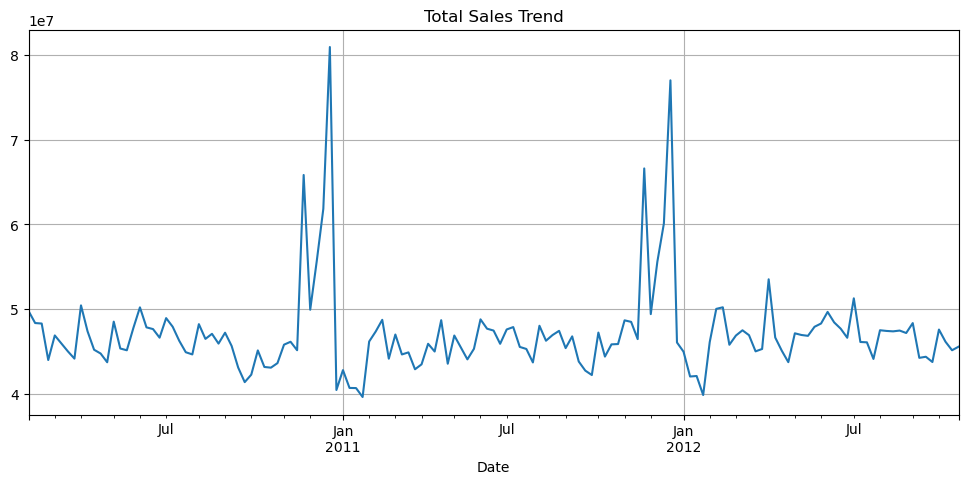

In [39]:
# Total Sales Trend 
df.groupby('Date')['Weekly_Sales'].sum().plot(figsize=(12,5))
plt.grid(True)
plt.title("Total Sales Trend")

In [30]:
# Store Type Analysis
df.groupby('Type')['Weekly_Sales'].sum().sort_values(ascending=False)

Type
A    4.331015e+09
B    2.000701e+09
C    4.055035e+08
Name: Weekly_Sales, dtype: float64

In [31]:
# Holiday Impact
df.groupby('IsHoliday')['Weekly_Sales'].mean()

IsHoliday
False    15901.445069
True     17035.823187
Name: Weekly_Sales, dtype: float64

In [32]:
# Top 10 Stores
df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False).head(10)

Store
20    3.013978e+08
4     2.995440e+08
14    2.889999e+08
13    2.865177e+08
2     2.753824e+08
10    2.716177e+08
27    2.538559e+08
6     2.237561e+08
1     2.224028e+08
39    2.074455e+08
Name: Weekly_Sales, dtype: float64

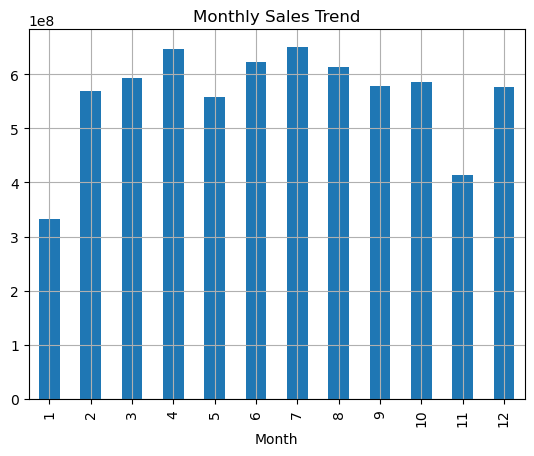

In [41]:
# Monthly Sales Trend
df['Month'] = df['Date'].dt.month

df.groupby('Month')['Weekly_Sales'].sum().plot(kind='bar')
plt.title("Monthly Sales Trend")
plt.grid(True)

<Axes: >

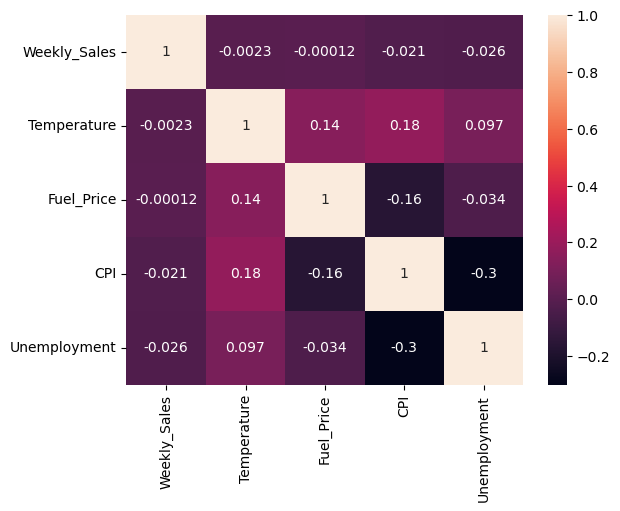

In [44]:
# Heatmap 
sns.heatmap(df[['Weekly_Sales','Temperature','Fuel_Price','CPI','Unemployment']].corr(), annot=True)

# Summary - Over View

This project focuses on analyzing retail sales data to identify trends, patterns, and business insights. The dataset consists of store-level weekly sales along with additional features such as holidays and store types.

Sales Trend Insight Sales show a seasonal pattern with noticeable spikes during specific periods, indicating higher consumer demand during holidays and festive seasons.

     Store Type Insight
Store Type A generates the highest revenue, likely due to larger store size and higher product variety.

     Holiday Impact Insight
Sales during holidays are higher compared to non-holiday periods, suggesting strong consumer spending during special occasions.

     Monthly Trend Insight
Sales peak during end-of-year months, indicating seasonal demand trends that businesses can leverage for promotions and inventory planning.

External Factors Insight (Heatmap)

(customize based on your result):

Temperature shows a slight correlation with sales, indicating that weather conditions may influence customer purchasing behavior.